# 트랜스포머와 전이학습 (26.9.10)

In [1]:
setence = ['The','cat','sat','on','the','mat']

attention_scores = {
    'The' : 0.1,
    'cat' : 1.0,
    'sat' : 0.8,
    'on' : 0.3,
    'the' : 0.1,
    'mat' : 0.6
}


In [2]:
word_vectors = {
    'The' : [0.1, 0.2, 0.3],
    'cat' : [0.5, 0.8, 0.2],
    'sat' : [0.7, 0.1, 0.9],
    'on' : [0.2, 0.6, 0.3],
    'the' : [0.1, 0.2, 0.3],
    'mat' : [0.8, 0.3, 0.5],
}

new_vector = []

for dim in range(3):
    weighted_sum =(
        0.1 * word_vectors['The'][dim] +
        1.0 * word_vectors['cat'][dim] +
        0.8 * word_vectors['sat'][dim] +
        0.3 * word_vectors['on'][dim] +
        0.1 * word_vectors['the'][dim] +
        0.6 * word_vectors['mat'][dim]
    )
    new_vector.append(weighted_sum)

print(word_vectors['cat'])
print(new_vector)


[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.37]


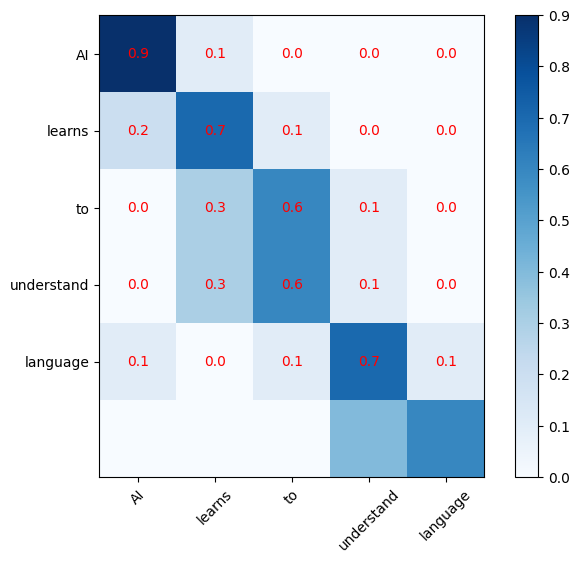

In [3]:
import matplotlib.pyplot as plt
import numpy as np

words = ['AI', 'learns', 'to', 'understand', 'language']

attention_matrix = np.array([
    [0.9, 0.1, 0.0, 0.0, 0.0],
    [0.2, 0.7, 0.1, 0.0, 0.0],
    [0.0, 0.3, 0.6, 0.1, 0.0],
    [0.0, 0.3, 0.6, 0.1, 0.0],
    [0.1, 0.0, 0.1, 0.7, 0.1],
    [0.0, 0.0, 0.0, 0.4, 0.6]
])

plt.figure(figsize = (8, 6))
plt.imshow(attention_matrix, cmap = 'Blues')
plt.xticks(range(len(words)), words, rotation = 45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f'{attention_matrix[i, j]:.1f}', ha = 'center', va = 'center', color = 'red')

plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:
    def __init__(self, d_model = 512):
        self.d_model = d_model
    def step_by_step_attention(self, sentence):
        words = sentence.split()
        vocab_size= len(words)
        embeddings = torch.randn(vocab_size, self.d_model)
        for i, word in enumerate(words):
            print(word, embeddings[i][:5].tolist())
        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @ W_q
        K = embeddings @ W_k
        V = embeddings @ W_v

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)
        print(scores.shape)

        attention_weights = F.softmax(scores, dim = 1)

        plt.figure(figsize = (10, 8))
        plt.imshow(attention_weights.detach().numpy(), cmap = 'Blues')
        plt.xticks(range(len(words)), words, rotation = 45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(
                    j, 
                    i, 
                    f'{attention_weights[i, j]:.2f}', 
                    ha = 'center', 
                    va = 'center', 
                    color = 'red' if attention_weights[i, j] > 0.3 else 'black'
                    )
        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()
        return output, attention_weights



In [7]:
def run_attention_demo():
    explainer = SelfAttentionExplainer()
    sentences = [
        'The cat sat on the mat',
        'AI learns to understand language',
        'Transformer models revolutionized NLP'
    ]

    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)
        

In [8]:
class PracticalAttentionExample:
    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim = 512,
            num_heads = 8,
            batch_first = True
        )

    def text_classification_with_attention(self):
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)
        attn_output, attn_weights = self.multihead_attn(
            text_embeddings, text_embeddings, text_embeddings
        )
        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)
        classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 3)
        )
        pooled = attn_output.mean(dim = 1)
        predictions = classifier(pooled)
        print(predictions.shape)
        return predictions



The [1.519523024559021, -1.5058395862579346, -0.27477124333381653, -0.4738064110279083, 0.6739994883537292]
cat [-0.7716460824012756, -1.3526067733764648, -0.8013757467269897, 1.4634068012237549, -0.34295493364334106]
sat [0.26156777143478394, -0.9777377843856812, 1.2635293006896973, 0.3424266576766968, -0.8273188471794128]
on [-0.0846216231584549, -0.2660022974014282, -1.1991137266159058, 1.117652177810669, -1.3009355068206787]
the [-0.5116440057754517, -0.022260792553424835, 0.23860198259353638, -1.121861219406128, -1.2595442533493042]
mat [2.06248140335083, 0.6810606122016907, 0.8457883596420288, -1.5866600275039673, 1.194799780845642]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 6])


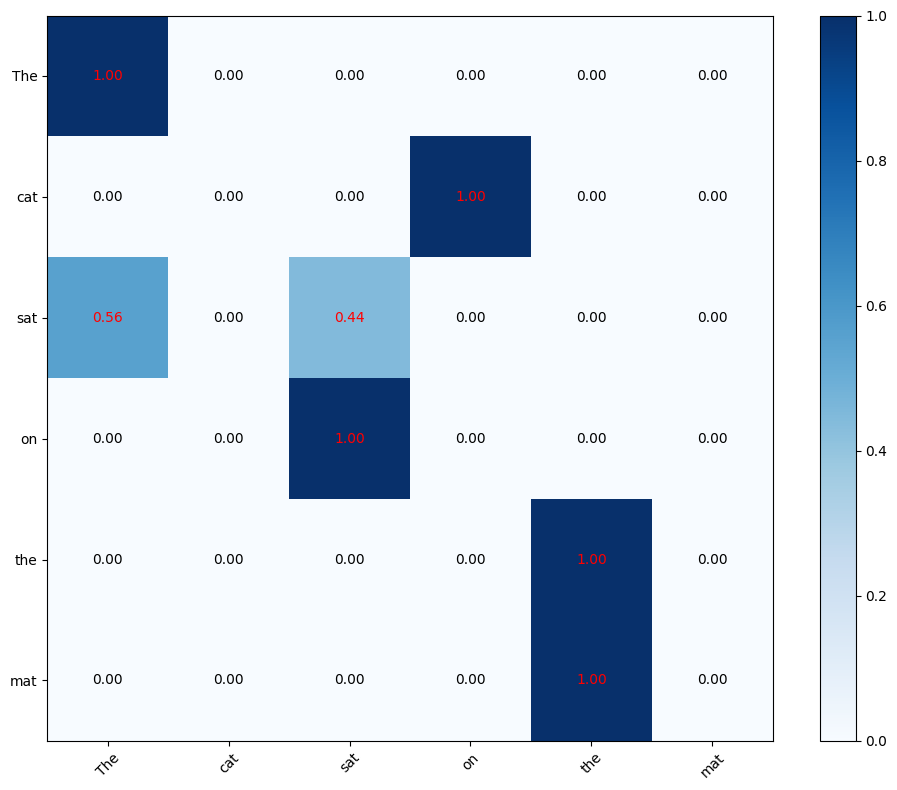

torch.Size([6, 512])
AI [-1.323659062385559, 0.8309704661369324, 0.9441940784454346, 0.8700960278511047, -0.691148042678833]
learns [1.7741856575012207, -0.2933875024318695, 0.016866585239768028, 1.3139152526855469, 0.6444858312606812]
to [1.1005163192749023, -0.6114115118980408, -0.13786828517913818, -0.18260309100151062, -1.2627692222595215]
understand [-0.6259531378746033, 0.5489861965179443, 1.576590895652771, 0.01801772601902485, 0.7730708718299866]
language [-1.3734076023101807, -1.1527427434921265, -3.3482470512390137, -0.22387707233428955, -0.0909918025135994]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 5])


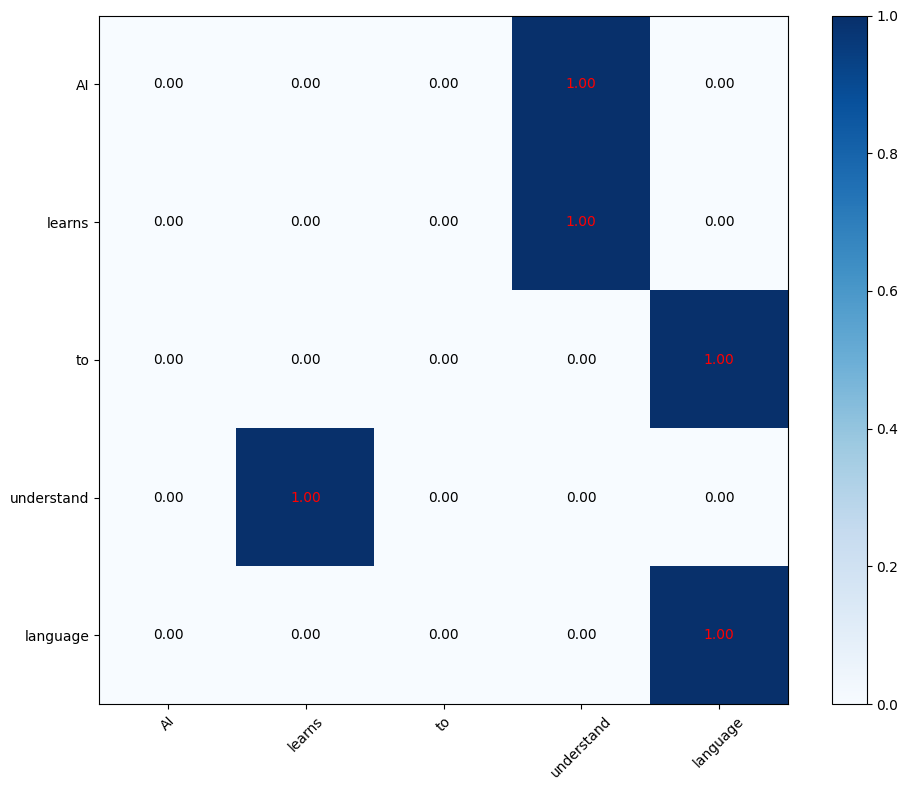

torch.Size([5, 512])
Transformer [0.34446197748184204, 0.2444044053554535, -0.24411983788013458, -0.5985697507858276, -0.7065821886062622]
models [-0.48127415776252747, 0.8290574550628662, -1.6196054220199585, 0.6445571780204773, -1.942952036857605]
revolutionized [-0.3551742136478424, -1.1811306476593018, 0.5444112420082092, 0.32278233766555786, 0.8492257595062256]
NLP [2.3425452709198, -1.3192230463027954, -0.5814480781555176, -0.6768106818199158, -0.9098139405250549]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 4])


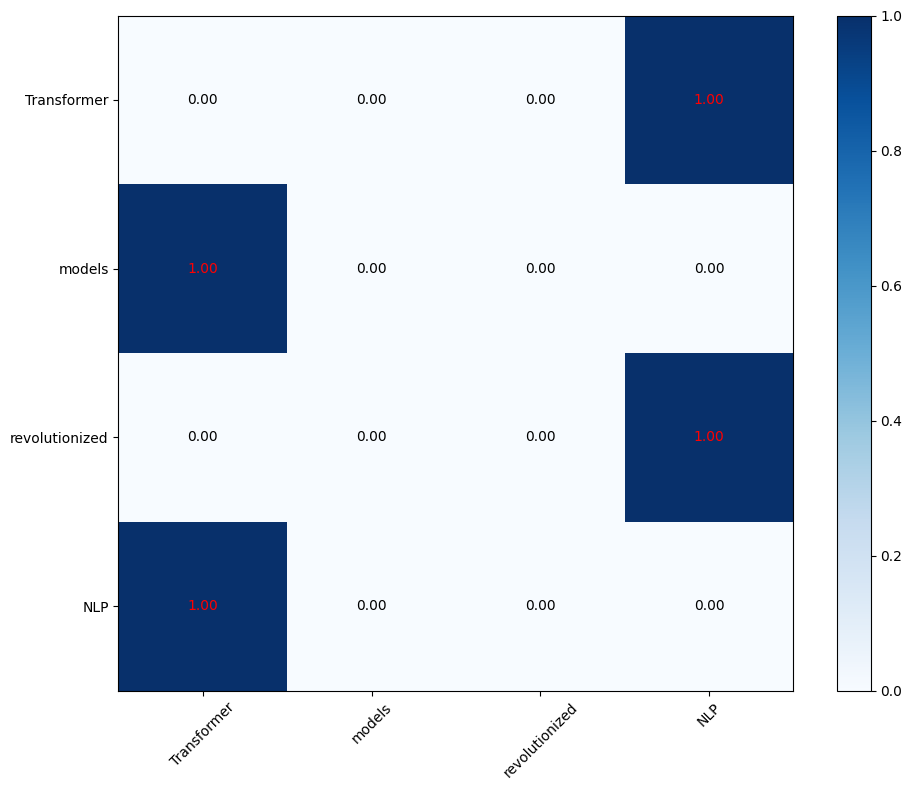

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[ 0.0788,  0.0022,  0.0224],
        [ 0.0801, -0.0144,  0.0342]], grad_fn=<AddmmBackward0>)

In [9]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()


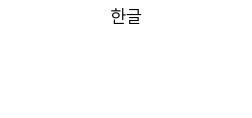

In [10]:
# 한글 폰트 설정 (윈도우)
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # 맑은 고딕
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지
plt.figure(figsize = (3,1))
plt.title("한글")
plt.axis("off")
plt.show()


In [14]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)

sentence = 'This movie was fantastic!'
inputs = tokenizer(sentence, return_tensors = 'pt', truncation = True, padding = True)
outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1


In [18]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sentences = ['I love this movie', 'I hate this movie', 'It was okay', 'Fantastic film', 'Terrible experience']
labels = torch.tensor([1, 0, 1, 1, 0])
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_inputs = tokenizer(sentences, padding = True, truncation = True, return_tensors = 'pt')
dataset = TensorDataset(encoded_inputs['input_ids'], labels)
train_loader = DataLoader(dataset, batch_size = 2, shuffle = True)

model_fe = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)

for param in model_fe.bert.parameters():
    param.requires_grad = False
optimizer_fe = optim.Adam(model_fe.parameters(), lr = 2e-5)
model_ft = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr = 2e-5)

def train_model(model, optimizer, epochs = 3):
    model.train()
    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids = input_ids, labels = label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
outputs = model_ft(**inputs)
lgits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

1


In [19]:
# ResNet을 활용한 전이학습

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained = True)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

img = Image.open('karina.jpg').convert('RGB')
img_t = transform(img)
img_t = img_t.unsqueeze(0)
outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

c:\Users\wm032\Documents\17_Deeplearning\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\wm032\Documents\17_Deeplearning\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\wm032/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 74.4MB/s]


0
